## **1: Project Title:** PhonePe Transaction Insights & Data Visualization using Python, SQL and Streamlit

- **Project Type:** Data Analytics Project (End-to-End Data Pipeline + Dashboard)

- **Contribution –** Individual

- **Name - Dharminder Singh Virk**

## **1.2: Project Summary:**

This project focuses on analyzing digital payment data from PhonePe to understand transaction patterns, user behavior, and geographical trends. The dataset was extracted from GitHub, transformed using Python, and stored in an SQL database. Various data analysis techniques and visualizations were applied to identify key insights such as top-performing states, districts, and transaction categories. An interactive dashboard was developed using Streamlit to present real-time insights and support business decision-making.

The screenshot of the Streamlit Dashboard attached below:

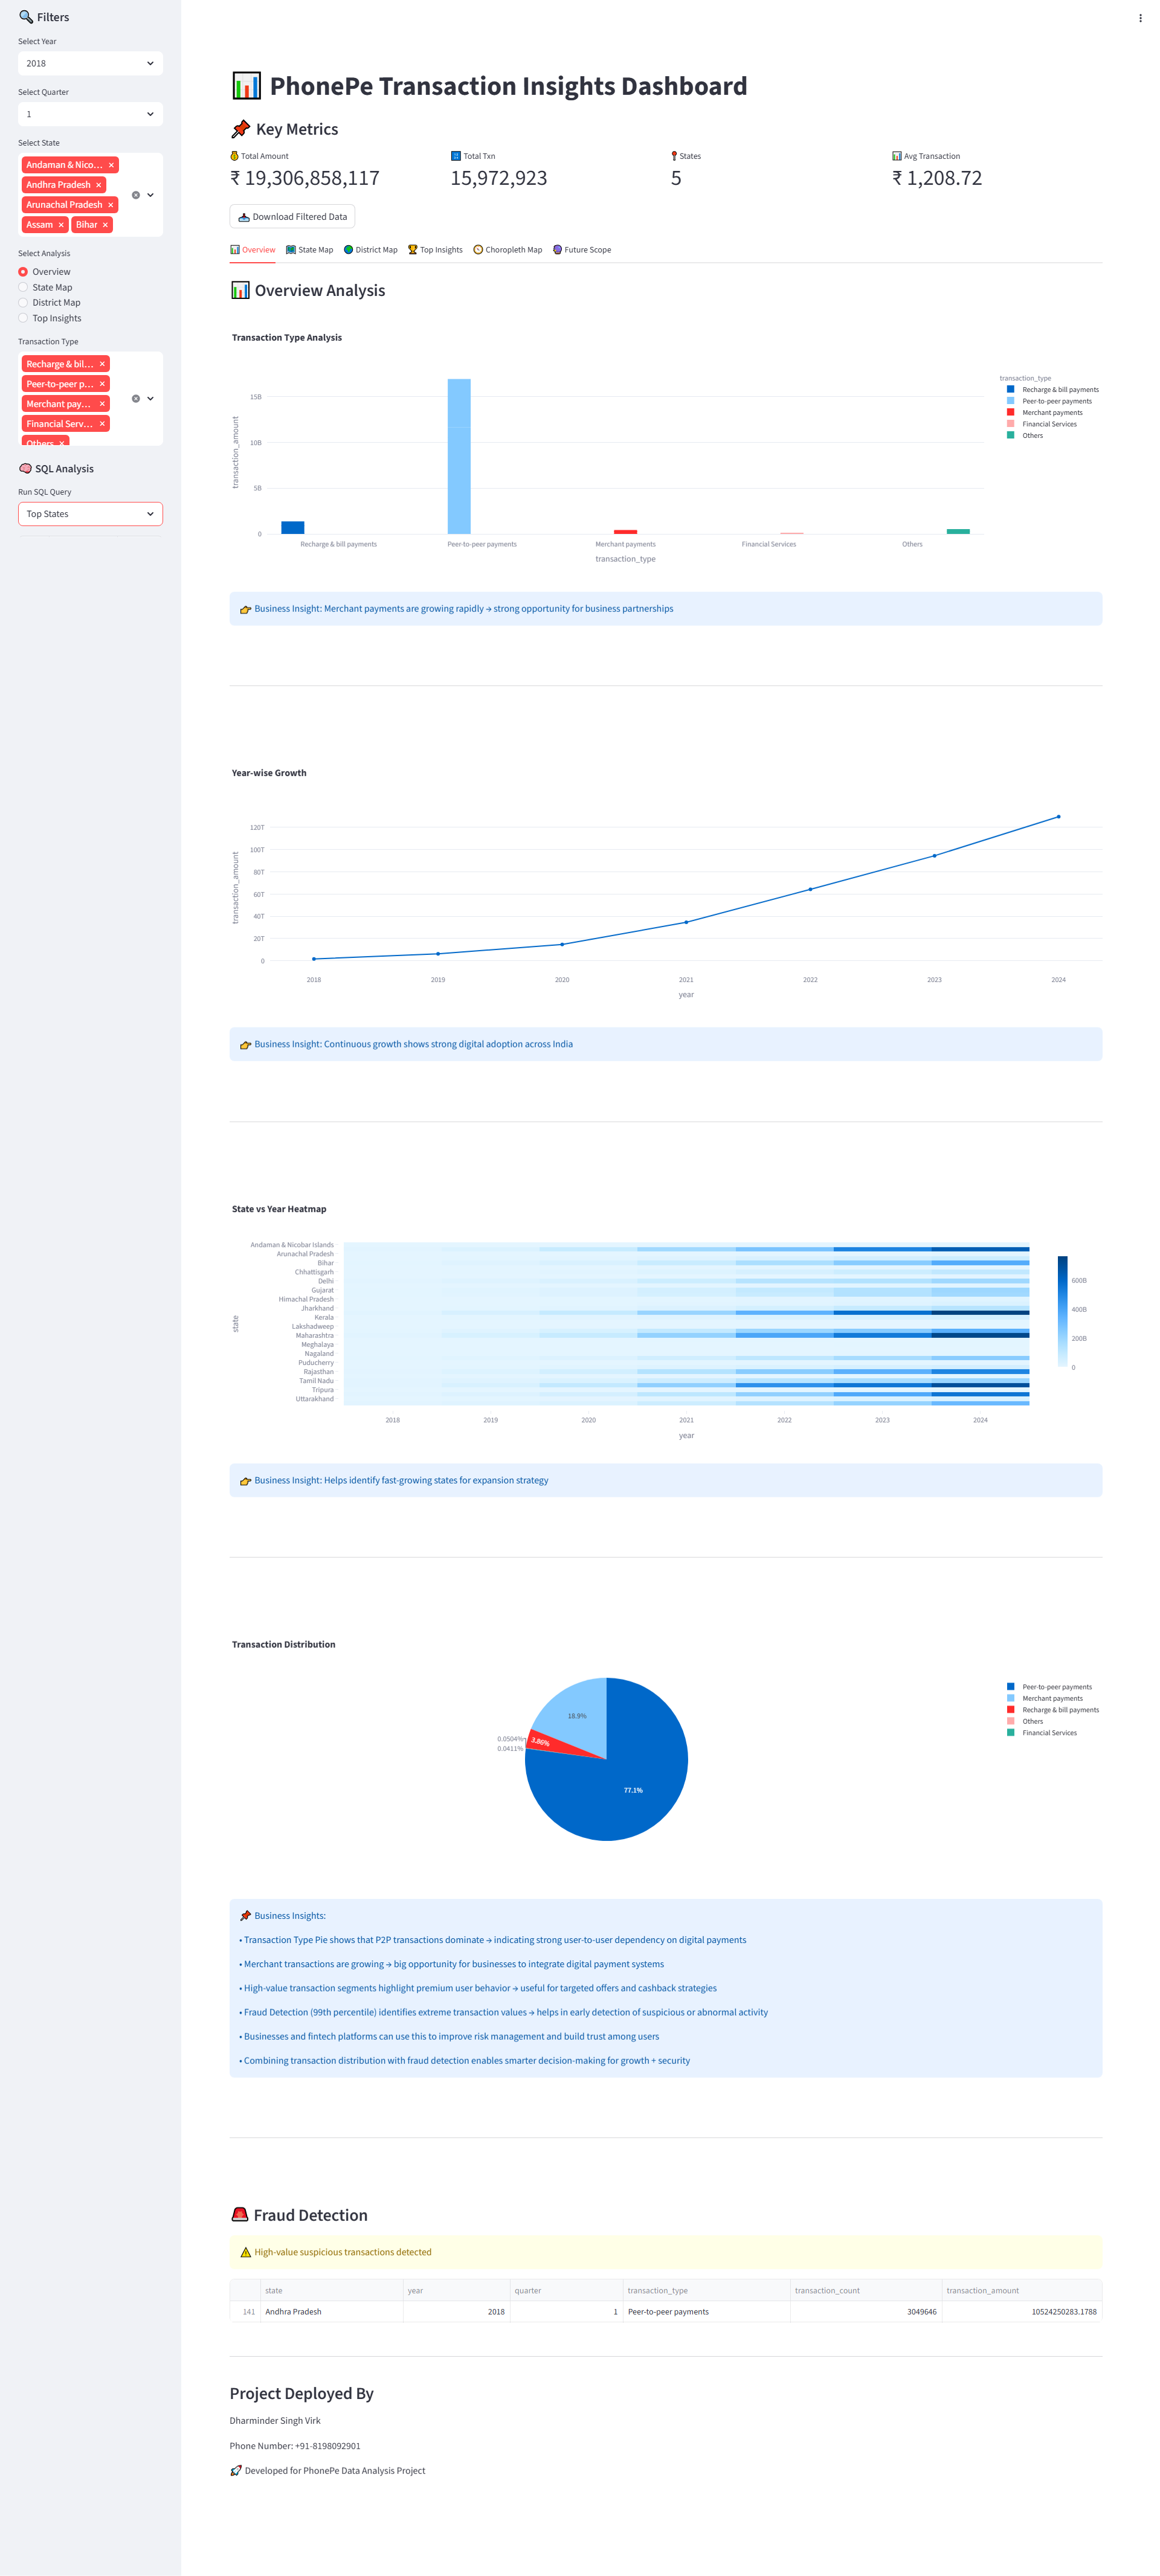

## **1.3: Data Description:**

The dataset is obtained from the PhonePe Pulse GitHub repository and consists of JSON files categorized into three main sections:

   1.   Aggregated Data  
        Contains summary-level data  
        Includes:
        *   Transaction Type
        *   Transaction Count
        *   Transaction Amount

   2.   Map Data
        Provides geographical data
        Includes:
        *   State-level data
        *   District-level data

   3.  Top Data
       Contains ranking-based data
       Includes:
       *   Top States
       *   Top Districts
       *   Top Pincodes

The data is structured in a hierarchical format:

State → Year → Quarter → JSON files

Each JSON file contains:
- Transaction details (type, count, amount)
- User data (registered users, app opens)
- Insurance data (policies, premium amounts)

## **1.4: Domain:**
- FinTech / Digital Payments / Data Analytics

## **1.5: Github Link:** https://github.com/dharmindersinghvirk25-creator/PhonePe-Transaction-Insights-Data-Visualization-using-Python-SQL-Streamlit-Application

## **1.6: Skills and Technologies Used:**
- Python
- SQL (SQLite)
- Data Cleaning & Transformation
- Exploratory Data Analysis (EDA)
- JSON Data Handling
- Data Visualization
- Streamlit Dashboard Development



## **1.7: Tools and Technologies Used:**
*   Google Colab
*   Python Libraries:
      
     *   Pandas
     *   Matplotlib
     *   Seaborn
     *   Plotly

*   SQLite Database
*   Streamlit
*   GitHub (for dataset)

## **1.8: Problem Statement:**

With the increasing adoption of digital payment platforms like PhonePe, it is essential to analyze transaction data to understand user behavior, detect trends, and identify high-performing regions. The challenge is to process large volumes of JSON-based data, transform it into a structured format, and generate meaningful insights that can help businesses improve services, optimize marketing strategies, and enhance user engagement.

## **1.9: Project Objectives:**

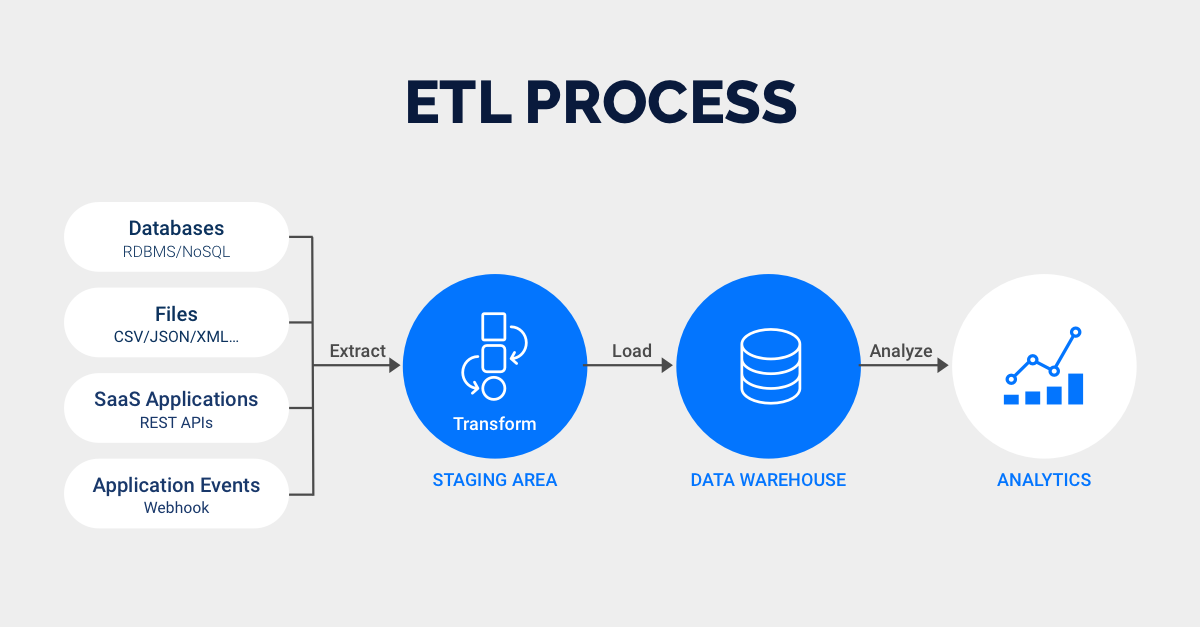










- Extract data from GitHub repository
- Transform JSON data into structured format
- Load data into SQL database
- Perform data analysis using SQL and Python
- Create visualizations to identify trends and patterns
- Develop an interactive dashboard using Streamlit
- Identify top-performing states, districts, and pincodes
- Detect potential fraudulent transactions

## **1.10: Business Use Cases:**

*   **Customer Segmentation:** Identify user groups based on transaction behavior
*   **Fraud Detection:** Detect abnormal or high-value transactions
*   **Geographical Insights:** Analyze transaction trends across states and districts
*   **Payment Performance:** Identify most used transaction types
*   **User Engagement:** Understand usage patterns to improve retention
*   **Product Development:** Improve services based on user behavior
*   **Insurance Insights:** Analyze insurance-related transactions
*   **Marketing Optimization:** Target high-performing regions
*   **Trend Analysis:** Analyze growth trends over time
*   **Competitive Benchmarking:** Compare digital adoption across regions


## **1.11: Approach:**

- Step 1: Data Extraction
    - Clone dataset from GitHub
    - Read JSON files using Python
- Step 2: Data Transformation
    - Extract required fields
    - Convert data into Pandas DataFrame
    - Clean and format data
- Step 3: Data Loading
    - Create SQLite database
    - Create tables:
    - aggregated_transaction
    - map_transaction
    - top_transaction
    - top_pincode
    - Insert data into tables
- Step 4: Data Analysis
    - Perform SQL queries
    - Identify trends and patterns
- Step 5: Data Visualization
    - Bar charts
    - Line charts
    - Pie charts
    - Heatmaps
    - Histogram
- Step 6: Dashboard Development
    - Build dashboard using Streamlit
    - Add filters, maps, insights
    - Deploy using ngrok

## **_Let's Begin!_**

## **PHASE 1: DATA EXTRACTION (ETL)**

### **_Phase 1.1: Understanding ETL Process_**

ETL (Extract, Transform, Load) is a data pipeline process:

- Extract → Collect data from GitHub (PhonePe Pulse dataset)
- Transform → Clean and structure JSON data using Python
- Load → Store processed data into SQL database

### **_1.2: Clone Dataset from GitHub_**

In [1]:
# Clone PhonePe dataset
!git clone https://github.com/PhonePe/pulse.git

Cloning into 'pulse'...
remote: Enumerating objects: 17904, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 17904 (delta 19), reused 17 (delta 17), pack-reused 17855 (from 2)
Receiving objects: 100% (17904/17904), 26.13 MiB | 18.42 MiB/s, done.
Resolving deltas: 100% (8723/8723), done.


### **_Phase 1.3: Verify Dataset Structure_**

In [2]:
# Check folder structure
!ls pulse/data

aggregated  map  top


## **_Phase 1.4: Data Structure Understanding_**

The dataset is divided into three main categories:

     1.   Aggregated Data

          *  Transactions
          *  Users
          *  Insurance

     2.   Map Data

          *  State-level data
          *  District-level data

     3.   Top Data
    
          *  Top states
          *  Top districts
          *  Top pincodes


## **_Phase 1.5: Hierarchical Structure_**

The dataset follows a structured hierarchy:

State → Year → Quarter → JSON files

Each JSON file contains:

- Transaction data (type, count, amount)
- User data (registered users, app opens)
- Insurance data (policies, premium)

### **_Phase 1.6: Import Required Libraries_**

In [3]:
import os
import json
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

### **_Phase 1.7: Define Base Path_**

In [4]:
base_path = "/content/pulse/data"

### **_Phase 1.8: Validate Dataset Loading_**

In [5]:
if os.path.exists(base_path):
    print("Dataset loaded successfully ✅")
else:
    print("Error loading dataset ❌")

Dataset loaded successfully ✅


## **PHASE 2: DATA TRANSFORMATION**

### **_Phase 2.1: Extract Aggregated Transaction Data_**

### _Explanation:_

Aggregated data provides state-level transaction details categorized by transaction type.

In [6]:
agg_data = []

path = os.path.join(base_path, "aggregated/transaction/country/india/state/")

for state in sorted(os.listdir(path)):
    for year in sorted(os.listdir(path + state + "/")):
        for file in sorted(os.listdir(path + state + "/" + year + "/")):

            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    data = json.load(f)
            except:
                continue

            for item in data["data"]["transactionData"]:
                for inst in item["paymentInstruments"]:
                    agg_data.append([
                        state,
                        int(year),
                        int(file.strip(".json")),
                        item["name"],
                        inst["count"],
                        inst["amount"]
                    ])

### **_Phase 2.1.1: Convert To Dataframe_**

In [7]:
df_agg = pd.DataFrame(agg_data, columns=[
    "state", "year", "quarter",
    "transaction_type",
    "transaction_count",
    "transaction_amount"
])

df_agg.head()


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### **_Phase 2.1.2: Clean Data_**

In [8]:
df_agg["state"] = df_agg["state"].str.replace("-", " ").str.title()

### **_Phase 2.1.3: Save Data_**

In [9]:
df_agg.to_csv("aggregated_transaction.csv", index=False)

### **_Phase 2.1.4: Extract Aggregated User Data_**

### _Explanation:_

This dataset contains user engagement metrics such as registered users and app opens.

In [10]:
agg_user = []

path = os.path.join(base_path, "aggregated/user/country/india/state/")

for state in sorted(os.listdir(path)):
    for year in sorted(os.listdir(path + state + "/")):
        for file in sorted(os.listdir(path + state + "/" + year + "/")):

            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    data = json.load(f)
            except:
                continue

            agg_user.append([
                state,
                int(year),
                int(file.strip(".json")),
                data["data"]["aggregated"]["registeredUsers"],
                data["data"]["aggregated"]["appOpens"]
            ])

df_agg_user = pd.DataFrame(agg_user, columns=[
    "state", "year", "quarter",
    "registered_users",
    "app_opens"
])

df_agg_user["state"] = df_agg_user["state"].str.replace("-", " ").str.title()

### **_Phase 2.1.5: Extract Aggregated Insurance Data_**

### _Explanation:_
This dataset includes insurance transactions such as policies and premium amounts.

In [11]:
agg_insurance = []

path = os.path.join(base_path, "aggregated/insurance/country/india/state/")

for state in sorted(os.listdir(path)):
    for year in sorted(os.listdir(path + state + "/")):
        for file in sorted(os.listdir(path + state + "/" + year + "/")):

            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    data = json.load(f)
            except:
                continue

            for item in data["data"]["transactionData"]:
                for inst in item["paymentInstruments"]:
                    agg_insurance.append([
                        state,
                        int(year),
                        int(file.strip(".json")),
                        item["name"],
                        inst["count"],
                        inst["amount"]
                    ])

df_agg_insurance = pd.DataFrame(agg_insurance, columns=[
    "state", "year", "quarter",
    "insurance_type",
    "count",
    "amount"
])

df_agg_insurance["state"] = df_agg_insurance["state"].str.replace("-", " ").str.title()

### **_Phase 2.2: Extract Map Transaction Data_**

### _Explanation:_

District-level transaction data used for geographical insights.

In [12]:
map_data = []

path = os.path.join(base_path, "map/transaction/hover/country/india/state/")

for state in sorted(os.listdir(path)):
    for year in sorted(os.listdir(path + state + "/")):
        for file in sorted(os.listdir(path + state + "/" + year + "/")):

            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    data = json.load(f)
            except:
                continue

            for item in data["data"]["hoverDataList"]:
                map_data.append([
                    state,
                    int(year),
                    int(file.strip(".json")),
                    item["name"],
                    item["metric"][0]["count"],
                    item["metric"][0]["amount"]
                ])

### **_Phase2.2.1: Convert To Dataframe_**

In [13]:
df_map = pd.DataFrame(map_data, columns=[
    "state", "year", "quarter",
    "district",
    "transaction_count",
    "transaction_amount"
])

df_map.head()

,state,year,quarter,district,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,north and middle andaman district,442,9.316631e+05
1,andaman-&-nicobar-islands,2018,1,south andaman district,5688,1.256025e+07
2,andaman-&-nicobar-islands,2018,1,nicobars district,528,1.139849e+06
3,andaman-&-nicobar-islands,2018,2,north and middle andaman district,825,1.317863e+06
4,andaman-&-nicobar-islands,2018,2,south andaman district,9395,2.394824e+07


### **_Phase 2.2.2: Clean Data_**

In [14]:
df_map["state"] = df_map["state"].str.replace("-", " ").str.title()

### **_Phase 2.2.3: Save Data_**

In [15]:
df_map.to_csv("map_transaction.csv", index=False)

### **_Phase 2.3: Extract Top Transaction Data_**

### _Explanation:_

Top data helps identify high-performing regions based on transaction volume and value, enabling better business decision-making.

In [16]:
top_data = []

path = os.path.join(base_path, "top/transaction/country/india/state/")

for state in sorted(os.listdir(path)):
    for year in sorted(os.listdir(path + state + "/")):
        for file in sorted(os.listdir(path + state + "/" + year + "/")):

            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    data = json.load(f)
            except:
                continue

            for item in data["data"]["districts"]:
                top_data.append([
                    state,
                    int(year),
                    int(file.strip(".json")),
                    item["entityName"],
                    item["metric"]["count"],
                    item["metric"]["amount"]
                ])

### **_Phase 2.3.1: Convert To Dataframe_**

In [17]:
df_top = pd.DataFrame(top_data, columns=[
    "state", "year", "quarter",
    "district",
    "transaction_count",
    "transaction_amount"
])

df_top.head()

,state,year,quarter,district,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,south andaman,5688,1.256025e+07
1,andaman-&-nicobar-islands,2018,1,nicobars,528,1.139849e+06
2,andaman-&-nicobar-islands,2018,1,north and middle andaman,442,9.316631e+05
3,andaman-&-nicobar-islands,2018,2,south andaman,9395,2.394824e+07
4,andaman-&-nicobar-islands,2018,2,nicobars,1120,3.072437e+06


### **_Phase 2.3.2: Clean Data_**

In [18]:
df_top["state"] = df_top["state"].str.replace("-", " ").str.title()

### **_Phase 2.3.3: Save Data_**

In [19]:
df_top.to_csv("top_transaction.csv", index=False)

### **_Phase 2.3.4: Extract Top Pincode Data_**

### _Explanation:_

This dataset helps identify high-value regions based on transaction activity at the pincode level.

In [20]:
pincode_list = []

path = os.path.join(base_path, "top/transaction/country/india/state/")

for state in sorted(os.listdir(path)):
    for year in sorted(os.listdir(path + state + "/")):
        for file in sorted(os.listdir(path + state + "/" + year + "/")):

            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    data = json.load(f)
            except:
                continue

            for item in data["data"]["pincodes"]:
                pincode_list.append([
                    state,
                    int(year),
                    int(file.strip(".json")),
                    item["entityName"],
                    item["metric"]["count"],
                    item["metric"]["amount"]
                ])

df_pincode = pd.DataFrame(pincode_list, columns=[
    "state", "year", "quarter",
    "pincode",
    "transaction_count",
    "transaction_amount"
])

df_pincode["state"] = df_pincode["state"].str.replace("-", " ").str.title()

df_pincode.head()

,state,year,quarter,pincode,transaction_count,transaction_amount
0,Andaman & Nicobar Islands,2018,1,744101,1622,2.769298e+06
1,Andaman & Nicobar Islands,2018,1,744103,1223,2.238042e+06
2,Andaman & Nicobar Islands,2018,1,744102,969,3.519060e+06
3,Andaman & Nicobar Islands,2018,1,744105,685,1.298561e+06
4,Andaman & Nicobar Islands,2018,1,744104,340,1.039715e+06


### _Explanation:_

Used to identify high-value user regions

## **PHASE 3: DATABASE (SQL)**

### **_Phase 3.1: Create Database Connection_**

### _Explanation:_

SQLite database is used for efficient storage and querying of structured data.

In [21]:
import sqlite3

conn = sqlite3.connect("phonepe.db")

### **_Phase 3.2: Load Data Into SQL Tables_**

### _Explanation:_

Pandas DataFrames are loaded into SQL tables for structured querying.

In [22]:
df_agg.to_sql("aggregated_transaction", conn, if_exists="replace", index=False)
df_agg_user.to_sql("aggregated_user", conn, if_exists="replace", index=False)
df_agg_insurance.to_sql("aggregated_insurance", conn, if_exists="replace", index=False)

df_map.to_sql("map_transaction", conn, if_exists="replace", index=False)

df_top.to_sql("top_transaction", conn, if_exists="replace", index=False)
df_pincode.to_sql("top_pincode", conn, if_exists="replace", index=False)

print("All tables created and data inserted ✅")

All tables created and data inserted ✅


### **_Phase 3.3: Load Data From Database_**

### _Explanation:_

Data is retrieved from SQL tables for analysis.

In [23]:
df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)
df_map = pd.read_sql("SELECT * FROM map_transaction", conn)
df_top = pd.read_sql("SELECT * FROM top_transaction", conn)
df_pincode = pd.read_sql("SELECT * FROM top_pincode", conn)

### **_Phase 3.4: Verify Tables In Database_**

In [24]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('aggregated_transaction',), ('aggregated_user',), ('aggregated_insurance',), ('map_transaction',), ('top_transaction',), ('top_pincode',)]


### **_Phase 3.5: Verify Sample Data_**

In [25]:
pd.read_sql("SELECT * FROM aggregated_transaction LIMIT 5", conn)

,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05


### **_Phase 3.6: Check Data Shape & Columns_**



In [26]:
print(df.shape)
print(df.columns)

(5034, 6)
Index(['state', 'year', 'quarter', 'transaction_type', 'transaction_count',
       'transaction_amount'],
      dtype='object')


## **PHASE 4: SQL DATA ANALYSIS**

### _Explanation:_

SQL queries are used to analyze transaction data and extract meaningful insights for business decision-making.

### **_Phase 4.1: Top Performing States_**

### _Explanation:_

Identify states with highest transaction amount.

In [27]:
pd.read_sql("""
SELECT state, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10;
""", conn)

,state,total_amount
0,Telangana,4.165596e+13
1,Karnataka,4.067872e+13
2,Maharashtra,4.037420e+13
3,Andhra Pradesh,3.466908e+13
4,Uttar Pradesh,2.688521e+13
5,Rajasthan,2.634324e+13
6,Madhya Pradesh,1.912528e+13
7,Bihar,1.790135e+13
8,West Bengal,1.558416e+13
9,Odisha,1.226398e+13


### **_Phase 4.2: Top Performing Districts_**

### _Explanation:_

Helps identify high-performing districts for targeted marketing.

In [28]:
pd.read_sql("""
SELECT district, SUM(transaction_amount) AS total_amount
FROM map_transaction
GROUP BY district
ORDER BY total_amount DESC
LIMIT 10;
""", conn)

,district,total_amount
0,bengaluru urban district,1.993784e+13
1,hyderabad district,1.190694e+13
2,pune district,9.730218e+12
3,jaipur district,7.854092e+12
4,rangareddy district,7.155140e+12
5,medchal malkajgiri district,5.758878e+12
6,visakhapatnam district,4.198568e+12
7,guntur district,3.174527e+12
8,krishna district,3.142856e+12
9,patna district,3.110762e+12


### **_Phase 4.3: Top Pincodes_**

### _Explanation:_

Identifies high-value regions at pincode level.

In [29]:
pd.read_sql("""
SELECT pincode, SUM(transaction_amount) AS total_amount
FROM top_pincode
GROUP BY pincode
ORDER BY total_amount DESC
LIMIT 10;
""", conn)

,pincode,total_amount
0,500001,2.930982e+12
1,500034,2.777747e+12
2,560001,2.151967e+12
3,110006,1.890727e+12
4,411004,1.800762e+12
5,302016,1.528114e+12
6,800001,1.500670e+12
7,302012,1.165971e+12
8,462008,1.052087e+12
9,500072,1.026144e+12


### **_Phase 4.4: Transaction Trend Over Time_**

### _Explanation:_

Analyzes growth of digital payments over years.

In [30]:
pd.read_sql("""
SELECT year, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY year
ORDER BY year;
""", conn)

,year,total_amount
0,2018,1.623045e+12
1,2019,6.276688e+12
2,2020,1.464116e+13
3,2021,3.459870e+13
4,2022,6.426633e+13
5,2023,9.449181e+13
6,2024,1.296246e+14


### **_Phase 4.5: Quarterly Trend Analysis_**

In [31]:
pd.read_sql("""
SELECT quarter, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY quarter
ORDER BY quarter;
""", conn)

,quarter,total_amount
0,1,7.335523e+13
1,2,8.202423e+13
2,3,8.823314e+13
3,4,1.019097e+14


### **_Phase 4.6: Transaction Type Analysis_**

### _Explanation:_

Identifies most used transaction categories.

In [32]:
pd.read_sql("""
SELECT transaction_type, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY transaction_type
ORDER BY total_amount DESC;
""", conn)

,transaction_type,total_amount
0,Peer-to-peer payments,2.665274e+14
1,Merchant payments,6.533988e+13
2,Recharge & bill payments,1.333876e+13
3,Others,1.742807e+11
4,Financial Services,1.420188e+11


### **_Phase 4.7: Customer Engagement (User Data)_**

In [33]:
pd.read_sql("""
SELECT state, SUM(registered_users) AS users
FROM aggregated_user
GROUP BY state
ORDER BY users DESC
LIMIT 10;
""", conn)

,state,users
0,Maharashtra,1140138243
1,Uttar Pradesh,942334146
2,Karnataka,733674236
3,Andhra Pradesh,556747126
4,Rajasthan,555774493
5,West Bengal,524964358
6,Telangana,524620520
7,Tamil Nadu,506486772
8,Madhya Pradesh,470663624
9,Gujarat,459154666


### **_Phase 4.8: Insurance Analysis_**

In [34]:
pd.read_sql("""
SELECT insurance_type, SUM(amount) AS total_amount
FROM aggregated_insurance
GROUP BY insurance_type
ORDER BY total_amount DESC;
""", conn)

,insurance_type,total_amount
0,Insurance,2.001558e+10


### **_Phase 4.9: Average Transaction Value_**

In [35]:
pd.read_sql("""
SELECT state,
SUM(transaction_amount)/SUM(transaction_count) AS avg_value
FROM aggregated_transaction
GROUP BY state
ORDER BY avg_value DESC
LIMIT 10;
""", conn)

,state,avg_value
0,Manipur,2539.397023
1,Nagaland,2380.164025
2,Mizoram,2359.883977
3,Ladakh,2261.853933
4,Meghalaya,1833.848173
5,Andhra Pradesh,1832.530061
6,Lakshadweep,1820.510982
7,Sikkim,1806.010952
8,Andaman & Nicobar Islands,1779.724994
9,Arunachal Pradesh,1712.827367


## **PHASE 5: DATA VISUALIZATION**

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### **_Phase 5.1: TOP STATES (Transaction Amount)_**

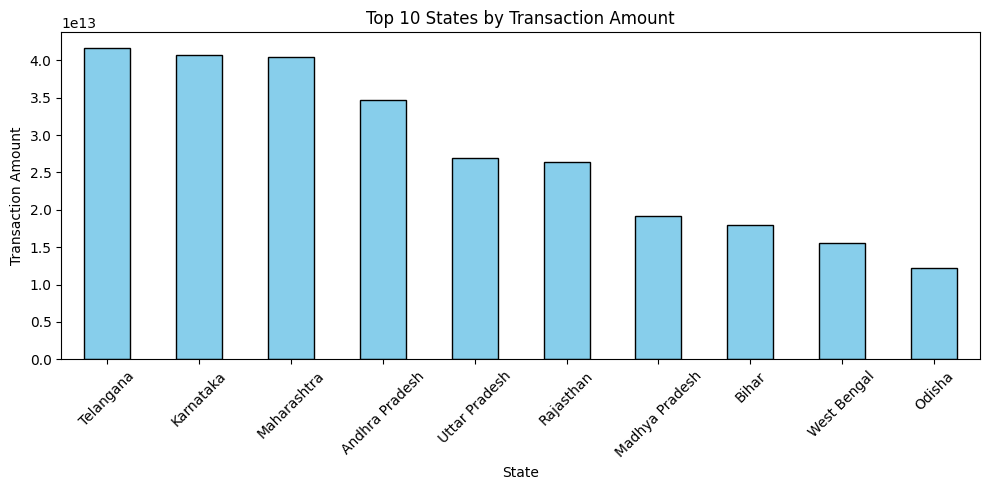

In [37]:
top_states = df.groupby("state")["transaction_amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top 10 States by Transaction Amount")
plt.xlabel("State")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()


### Insight:

Top states indicate high digital adoption. Businesses can target these regions for premium services.



### **_Phase 5.2: YEAR-WISE TREND_**

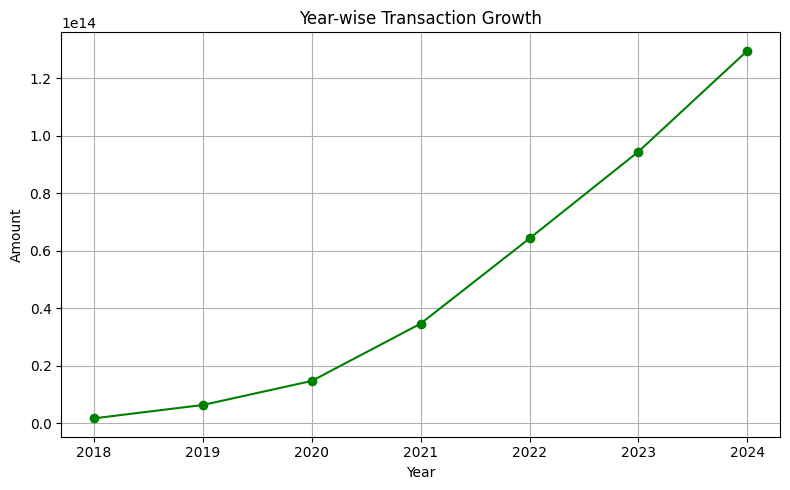

In [38]:
year_data = df.groupby("year")["transaction_amount"].sum()

plt.figure(figsize=(8,5))
year_data.plot(marker='o', color='green')
plt.title("Year-wise Transaction Growth")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.grid()
plt.tight_layout()
plt.show()

### Insight:

Continuous growth reflects expansion of the digital economy and helps in forecasting trends.





### **_Phase 5.3: QUARTER ANALYSIS_**

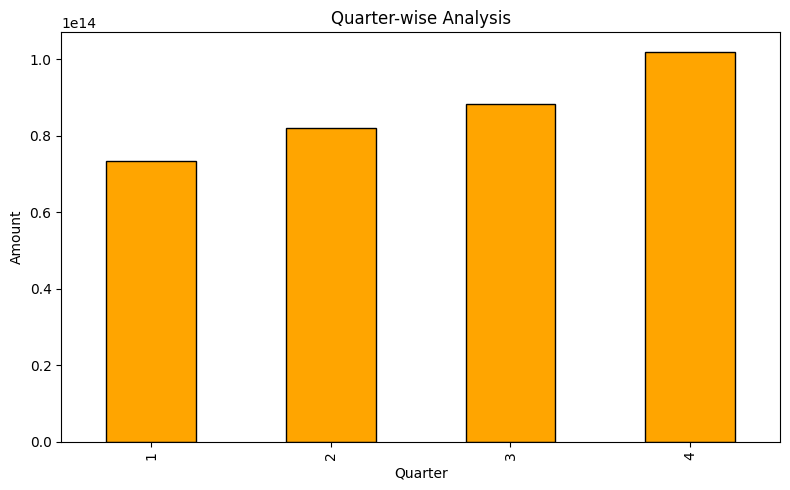

In [39]:
quarter_data = df.groupby("quarter")["transaction_amount"].sum()

plt.figure(figsize=(8,5))
quarter_data.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Quarter-wise Analysis")
plt.xlabel("Quarter")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

### Insight:

Seasonal spikes help in planning marketing campaigns.





### **_Phase 5.4: TRANSACTION TYPE DISTRIBUTION (PIE CHART)_**

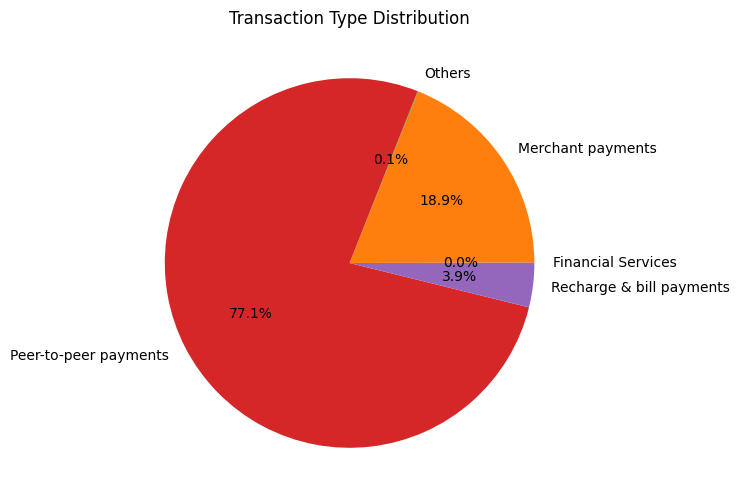

In [40]:
type_data = df.groupby("transaction_type")["transaction_amount"].sum()

plt.figure(figsize=(6,6))
plt.pie(type_data, labels=type_data.index, autopct='%1.1f%%')
plt.title("Transaction Type Distribution")
plt.show()

### Insight:

P2P dominates, while merchant payments show growth opportunities.





### **_Phase 5.5: HEATMAP (STATE vs YEAR)_**

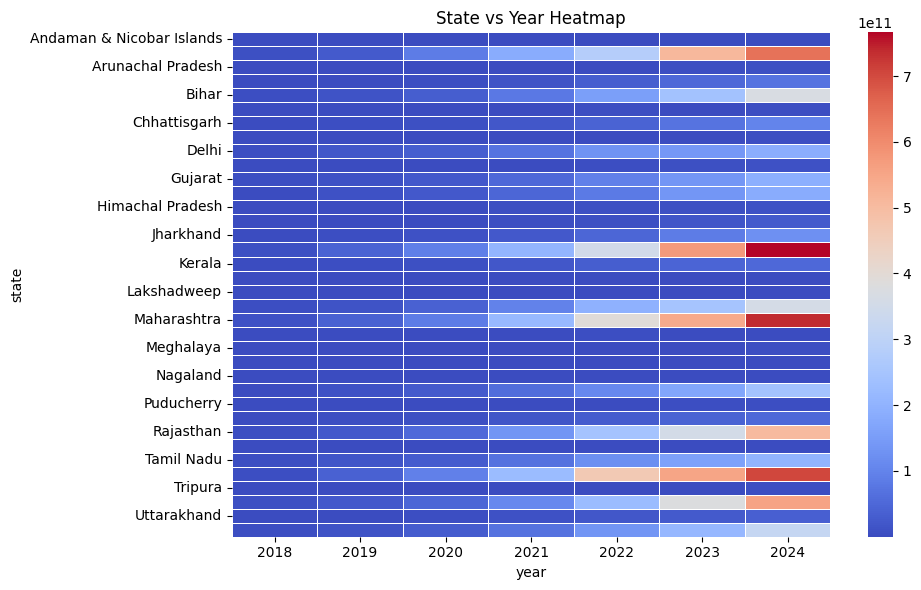

In [41]:
pivot = df.pivot_table(values="transaction_amount", index="state", columns="year")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="coolwarm", linewidths=0.5)
plt.title("State vs Year Heatmap")
plt.tight_layout()
plt.show()

### Insight:

Helps identify fast-growing states for regional strategy.





### **_Phase 5.6: Top DISTRICTS_**

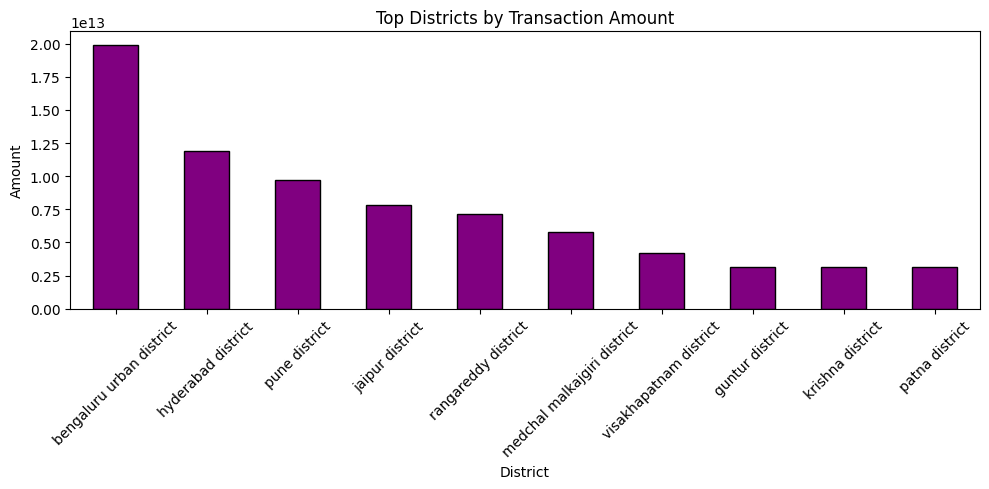

In [42]:
top_districts = df_map.groupby("district")["transaction_amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_districts.plot(kind='bar', color='purple', edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top Districts by Transaction Amount")
plt.xlabel("District")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

### Insight:

High-performing districts represent major business hubs.





### **_Phase 5.7: TOP PINCODES_**

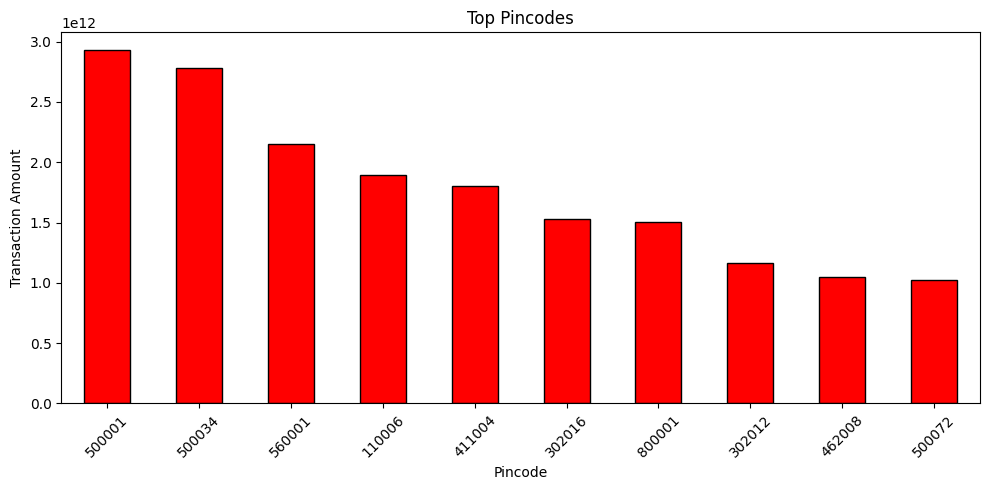

In [43]:
top_pin = df_pincode.groupby("pincode")["transaction_amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_pin.plot(kind='bar', color='red', edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top Pincodes")
plt.xlabel("Pincode")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

### Insight:

Identifies high-value regions for business expansion.

### **_Phase 5.8: AVERAGE TRANSACTION DISTRIBUTION_**

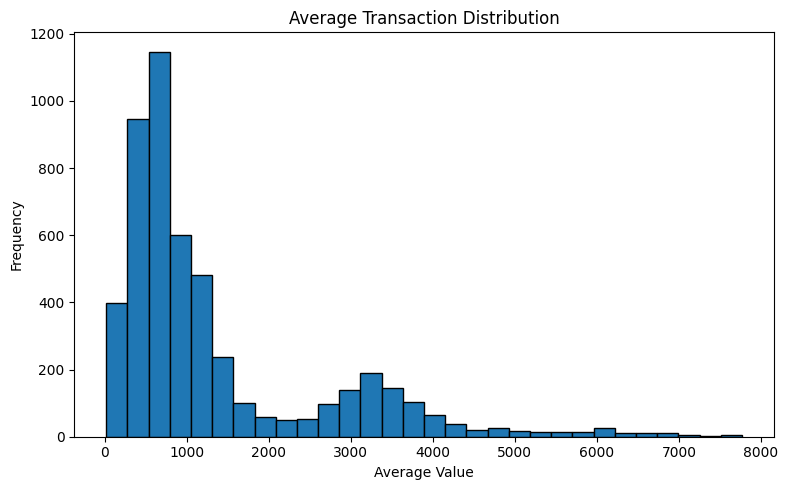

In [44]:
avg_txn = df["transaction_amount"] / df["transaction_count"]

plt.figure(figsize=(8,5))
plt.hist(avg_txn, bins=30, edgecolor='black')
plt.title("Average Transaction Distribution")
plt.xlabel("Average Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight:

Higher average values indicate premium users.




### **_Phase 5.9: DISTRICT-LEVEL ANALYSIS_**

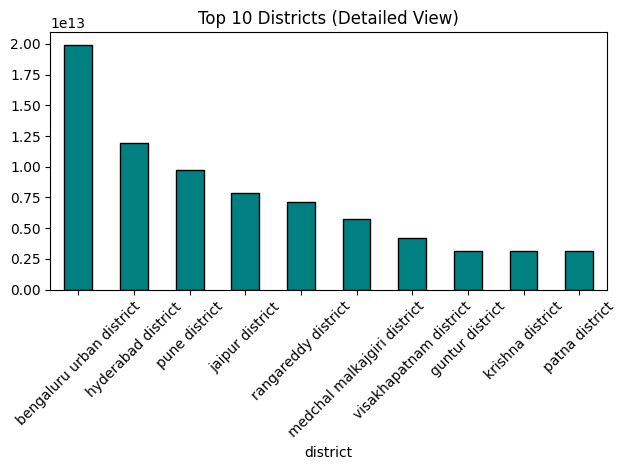

In [45]:
df_map.groupby("district")["transaction_amount"].sum().nlargest(10).plot(kind="bar", color='teal', edgecolor='black')
plt.title("Top 10 Districts (Detailed View)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight:

Supports hyperlocal marketing strategies.





### **_Phase 5.10: FRAUD DETECTION_**

In [46]:
threshold = df["transaction_amount"].quantile(0.99)
fraud = df[df["transaction_amount"] > threshold]

print("Potential Fraud Transactions:")
print(fraud.head())

Potential Fraud Transactions:
              state  year  quarter       transaction_type  transaction_count  \
241  Andhra Pradesh  2023        1  Peer-to-peer payments          514931308   
246  Andhra Pradesh  2023        2  Peer-to-peer payments          573455382   
251  Andhra Pradesh  2023        3  Peer-to-peer payments          623202203   
256  Andhra Pradesh  2023        4  Peer-to-peer payments          673002314   
261  Andhra Pradesh  2024        1  Peer-to-peer payments          721764113   

     transaction_amount  
241        1.857818e+12  
246        2.067288e+12  
251        2.163465e+12  
256        2.270767e+12  
261        2.436666e+12  


### Insight:

Extremely high transactions may indicate suspicious activity.


### **_Phase 5.11: CHOROPLETH MAP (STATE-WISE)_**

In [47]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv("aggregated_transaction.csv")

# Aggregate
state_data = df.groupby("state")["transaction_amount"].sum().reset_index()

# ✅ Direct GeoJSON URL
geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"

fig = px.choropleth(
    state_data,
    geojson=geojson_url,
    featureidkey="properties.NAME_1",
    locations="state",
    color="transaction_amount",
    color_continuous_scale="Viridis",
    title="India State-wise Transaction Distribution"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()




### Insight:

Visual representation of transaction density across India.

Note:
Due to limitations in accessing external GeoJSON files, Plotly built-in maps are used for visualization. This provides an approximate geographical representation of transaction distribution.

### **_Phase 5.12: KPI METRICS SUMMARY_**

In [48]:
total_txn = df["transaction_amount"].sum()
total_count = df["transaction_count"].sum()
avg_txn = total_txn / total_count

print("Total Transaction Amount:", total_txn)
print("Total Transaction Count:", total_count)
print("Average Transaction Value:", avg_txn)

Total Transaction Amount: 345522294835386.5
Total Transaction Count: 235284216874
Average Transaction Value: 1468.5315463400652


### Insight:

Provides a quick overview of overall system performance.

## **PHASE 6: STREAMLIT DASHBOARD**

### **_Phase 6.1: Install & Setup_**

In [49]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.0 MB/s eta 0:00:00


In [50]:
!ls

aggregated_transaction.csv  phonepe.db	sample_data
map_transaction.csv	    pulse	top_transaction.csv


In [ ]:
pip install geopandas

### **_Phase 6.2: Creating Streamlit Application_**

The Streamlit application was developed to create an interactive and user-friendly dashboard for analyzing PhonePe transaction data. The application connects to a SQLite database and retrieves data from multiple tables such as aggregated transactions, map transactions, and top transaction datasets.

Various Python libraries like Pandas, Plotly, and PyDeck were used for data processing and visualization. Streamlit components such as sidebar filters, tabs, and metrics were implemented to enhance user interaction.

The application allows users to filter data based on year, quarter, state, and transaction type. It also supports SQL-based analysis for dynamic insights.


### **_Phase 6.3: Running Streamlit in Google Colab using Ngrok_**
Since Google Colab does not directly support hosting web applications, Ngrok was used to generate a public URL for accessing the Streamlit application.

Ngrok creates a secure tunnel from the public internet to the local environment where the Streamlit app is running.

In [54]:
%%writefile app.py
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
import pydeck as pdk

# -------------------------------
# PAGE CONFIG
# -------------------------------
st.set_page_config(page_title="PhonePe Insights", layout="wide")

st.title("📊 PhonePe Transaction Insights Dashboard")


# -------------------------------
# DATABASE CONNECTION
# -------------------------------
conn = sqlite3.connect("phonepe.db")

df = pd.read_sql("SELECT * FROM aggregated_transaction", conn)

# Load additional tables
try:
    df_map = pd.read_sql("SELECT * FROM map_transaction", conn)
except:
    df_map = pd.DataFrame()

try:
    df_top = pd.read_sql("SELECT * FROM top_transaction", conn)
except:
    df_top = pd.DataFrame()

try:
    df_pincode = pd.read_sql("SELECT * FROM top_pincode", conn)
except:
    df_pincode = pd.DataFrame()



# -------------------------------
# SIDEBAR FILTERS
# -------------------------------
st.sidebar.header("🔍 Filters")

year = st.sidebar.selectbox("Select Year", sorted(df["year"].unique()))
quarter = st.sidebar.selectbox("Select Quarter", sorted(df["quarter"].unique()))

state_filter = st.sidebar.multiselect(
    "Select State",
    df["state"].unique(),
    default=df["state"].unique()[:5]
)

analysis_type = st.sidebar.radio(
    "Select Analysis",
    ["Overview", "State Map", "District Map", "Top Insights"]
)

txn_type = st.sidebar.multiselect(
    "Transaction Type",
    df["transaction_type"].unique(),
    default=df["transaction_type"].unique()
)

# -------------------------------
# SQL QUERY SELECTOR
# -------------------------------
st.sidebar.subheader("🧠 SQL Analysis")

query_option = st.sidebar.selectbox("Run SQL Query", [
    "None",
    "Top States",
    "Year Trend",
    "Transaction Type"
])

if query_option == "Top States":
    query = """
    SELECT state, SUM(transaction_amount) as total
    FROM aggregated_transaction
    GROUP BY state
    ORDER BY total DESC
    LIMIT 10
    """
    st.sidebar.write(pd.read_sql(query, conn))

elif query_option == "Year Trend":
    query = """
    SELECT year, SUM(transaction_amount) as total
    FROM aggregated_transaction
    GROUP BY year
    """
    st.sidebar.write(pd.read_sql(query, conn))

elif query_option == "Transaction Type":
    query = """
    SELECT transaction_type, SUM(transaction_amount) as total
    FROM aggregated_transaction
    GROUP BY transaction_type
    """
    st.sidebar.write(pd.read_sql(query, conn))

# -------------------------------
# FILTER DATA
# -------------------------------
filtered_df = df[
    (df["year"] == year) &
    (df["quarter"] == quarter) &
    (df["state"].isin(state_filter))
]

# -------------------------------
# KPI METRICS (IMPROVED)
# -------------------------------
st.subheader("📌 Key Metrics")

col1, col2, col3, col4 = st.columns(4)

col1.metric("💰 Total Amount", f"₹ {filtered_df['transaction_amount'].sum():,.0f}")
col2.metric("🔢 Total Txn", f"{filtered_df['transaction_count'].sum():,}")
col3.metric("📍 States", filtered_df["state"].nunique())

avg_txn = filtered_df['transaction_amount'].sum() / filtered_df['transaction_count'].sum()
col4.metric("📊 Avg Transaction", f"₹ {avg_txn:,.2f}")

# Download button
st.download_button(
    label="📥 Download Filtered Data",
    data=filtered_df.to_csv(index=False),
    file_name="filtered_data.csv",
    mime="text/csv"
)

# -------------------------------
# TABS (NEW TAB ADDED)
# -------------------------------
tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
    "📊 Overview",
    "🗺️ State Map",
    "🌍 District Map",
    "🏆 Top Insights",
    "🧭 Choropleth Map",
    "🔮 Future Scope"
])

# ===============================
# 📊 TAB 1: OVERVIEW
# ===============================
with tab1:

    st.subheader("📊 Overview Analysis")

    fig1 = px.bar(filtered_df,
                  x="transaction_type",
                  y="transaction_amount",
                  color="transaction_type",
                  title="Transaction Type Analysis")
    st.plotly_chart(fig1, use_container_width=True)

    st.info("👉 Business Insight: Merchant payments are growing rapidly → strong opportunity for business partnerships")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    fig2 = px.line(
        df.groupby("year")["transaction_amount"].sum().reset_index(),
        x="year",
        y="transaction_amount",
        markers=True,
        title="Year-wise Growth"
    )
    st.plotly_chart(fig2, use_container_width=True)

    st.info("👉 Business Insight: Continuous growth shows strong digital adoption across India")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    # Heatmap (NEW)
    pivot = df.pivot_table(values="transaction_amount", index="state", columns="year")
    fig_heat = px.imshow(pivot, title="State vs Year Heatmap")
    st.plotly_chart(fig_heat)

    st.info("👉 Business Insight: Helps identify fast-growing states for expansion strategy")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    type_data = df.groupby("transaction_type")["transaction_amount"].sum()

    fig_pie = px.pie(
        values=type_data.values,
        names=type_data.index,
        title="Transaction Distribution"
    )
    st.plotly_chart(fig_pie)

    st.info("""
📌 Business Insights:\n\n

• Transaction Type Pie shows that P2P transactions dominate → indicating strong user-to-user dependency on digital payments\n\n
• Merchant transactions are growing → big opportunity for businesses to integrate digital payment systems\n\n
• High-value transaction segments highlight premium user behavior → useful for targeted offers and cashback strategies\n\n
• Fraud Detection (99th percentile) identifies extreme transaction values → helps in early detection of suspicious or abnormal activity\n\n
• Businesses and fintech platforms can use this to improve risk management and build trust among users\n\n
• Combining transaction distribution with fraud detection enables smarter decision-making for growth + security\n\n
""")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    # ✅ FIXED INDENTATION HERE
    threshold = filtered_df["transaction_amount"].quantile(0.99)
    fraud_df = filtered_df[filtered_df["transaction_amount"] > threshold]

    st.subheader("🚨 Fraud Detection")

    if not fraud_df.empty:
        st.warning("⚠️ High-value suspicious transactions detected")
        st.dataframe(fraud_df)
    else:
        st.success("✅ No suspicious activity found")




# ===============================
# 🗺️ TAB 2: STATE MAP (FIXED)
# ===============================
with tab2:

    st.subheader("🗺️ State-wise Transaction Map")

    # Aggregate data
    state_map = df.groupby("state")["transaction_amount"].sum().reset_index()

    # GeoJSON URL
    geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"

    # ✅ MAP 1 (Improved with hover)
    fig_map = px.choropleth(
        state_map,
        geojson=geojson_url,
        featureidkey="properties.NAME_1",
        locations="state",
        color="transaction_amount",
        color_continuous_scale="Viridis",
        hover_name="state",
        hover_data={"transaction_amount": True},
        title="India State Transaction Distribution"
    )

    fig_map.update_geos(fitbounds="locations", visible=False)

    st.plotly_chart(fig_map, use_container_width=True)

    st.info("👉 Business Insight: Helps identify top-performing states for targeted marketing")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    # =========================
    # 🎬 MAP 2 (FIXED ANIMATION)
    # =========================
    st.subheader("🎬 Year-wise Animation Map")

    # ✅ IMPORTANT FIX
    anim_data = df.groupby(["year", "state"])["transaction_amount"].sum().reset_index()

    fig_anim = px.choropleth(
        anim_data,
        geojson=geojson_url,
        featureidkey="properties.NAME_1",
        locations="state",
        color="transaction_amount",
        animation_frame="year",
        color_continuous_scale="Plasma",
        title="Year-wise Transaction Growth"
    )

    fig_anim.update_geos(fitbounds="locations", visible=False)

    st.plotly_chart(fig_anim, use_container_width=True)

    st.info("""
👉 Business Insight:\n\n

• Shows year-wise growth of digital payments\n\n
• Identifies fast-growing states\n\n
• Helps in trend analysis and forecasting\n\n
• Useful for expansion planning\n\n
""")


# ===============================
# 🌍 TAB 3: DISTRICT MAP
# ===============================
with tab3:

    st.subheader("🌍 District Level Map")

    df_geo = filtered_df.copy()

    df_geo["lat"] = 20 + (df_geo.index % 10)
    df_geo["lon"] = 78 + (df_geo.index % 10)

    layer = pdk.Layer(
        "ScatterplotLayer",
        data=df_geo,
        get_position='[lon, lat]',
        get_color='[0, 0, 255, 160]',
        get_radius=20000,
    )

    view_state = pdk.ViewState(latitude=22, longitude=78, zoom=4)

    r = pdk.Deck(layers=[layer], initial_view_state=view_state)

    st.pydeck_chart(r)

    st.info("""
👉  **Business Insight:**

• This district-level map provides granular visibility into transaction distribution \n\n
• Helps identify high-activity districts with strong digital payment adoption \n\n
• Enables hyperlocal targeting for marketing campaigns and merchant onboarding \n\n
• Businesses can focus on high-performing districts for premium services \n\n
• Low-activity districts highlight potential growth and expansion opportunities \n\n
""")

# ===============================
# 🏆 TAB 4: TOP INSIGHTS
# ===============================
with tab4:

    st.subheader("🏆 Top Insights & Business Analysis")

    # -----------------------
    # Top States
    # -----------------------
    st.subheader("Top States")

    top_states = (
        df.groupby("state")["transaction_amount"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    st.bar_chart(top_states)

    st.info("👉 Insight: Top states show highest digital adoption")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    # -----------------------
    # Top Districts
    # -----------------------
    st.subheader("Top Districts")

    if not df_map.empty and "district" in df_map.columns:
        top_districts = (
            df_map.groupby("district")["transaction_amount"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )
        st.bar_chart(top_districts)
        st.info("👉 Insight: High-performing districts are key growth zones")
    else:
        st.warning("⚠️ District data not available")

    st.markdown("<br><br><hr><br><br>", unsafe_allow_html=True)

    # -----------------------
    # ✅ Top Pincode (FIXED)
    # -----------------------
    st.subheader("Top Pincode")

    if not df_pincode.empty and "pincode" in df_pincode.columns:

        top_pin = (
            df_pincode.groupby("pincode")["transaction_amount"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )

        st.bar_chart(top_pin)

        st.success("✅ Using actual pincode data")

    elif not df_top.empty and "district" in df_top.columns:

        st.warning("⚠️ Pincode data not available → using district as proxy")

        top_pin = (
            df_top.groupby("district")["transaction_amount"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )

        st.bar_chart(top_pin)

    else:
        st.error("❌ No data available for pincode analysis")






# ===============================
# 🧭 TAB 5: ADVANCED CHOROPLETH
# ===============================
with tab5:

    st.subheader("🧭 Advanced Choropleth Map (High-Value States)")

    # GeoJSON URL
    geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"

    # ✅ Threshold (Top 10% states)
    threshold = df["transaction_amount"].quantile(0.90)

    high_value_states = (
        df.groupby("state")["transaction_amount"]
        .sum()
        .reset_index()
    )

    high_value_states = high_value_states[
        high_value_states["transaction_amount"] > threshold
    ]

    # ✅ ADVANCED MAP (Different from Tab 2)
    fig = px.choropleth(
        high_value_states,
        geojson=geojson_url,
        featureidkey="properties.NAME_1",
        locations="state",
        color="transaction_amount",
        color_continuous_scale="Reds",
        title="High-Value Transaction States (Top 10%)"
    )

    fig.update_geos(fitbounds="locations", visible=False)

    st.plotly_chart(fig, use_container_width=True)

    st.success("""
👉 Advanced Business Insight:\n\n

• Shows only top-performing states\n\n
• Helps focus on high-revenue markets\n\n
• Best for premium targeting\n\n
• Supports investment decisions\n\n
• Removes low-value noise from analysis\n\n
""")

# ===============================
# 🔮 TAB 6: FUTURE SCOPE
# ===============================
with tab6:

    st.subheader("🔮 Future Scope")

    st.markdown("""
### 🚀 Future Enhancements

- Real-time data integration using APIs\n\n
- Advanced fraud detection using Machine Learning\n\n
- District-level GeoJSON mapping for accurate visualization\n\n
- Customer segmentation using clustering algorithms\n\n
- Predictive analytics for transaction forecasting\n\n
- Integration with business dashboards (Power BI/Tableau)\n\n
- Mobile-friendly dashboard deployment\n\n

### 📈 Business Impact

- Better targeting strategies\n\n
- Improved fraud prevention\n\n
- Enhanced customer experience\n\n
- Data-driven decision making\n\n
    """)

# -----------------------------
# FOOTER
# -----------------------------
st.markdown("---")
st.markdown("""
### Project Deployed By

Dharminder Singh Virk\n\n
Phone Number: +91-8198092901\n\n
🚀 Developed for PhonePe Data Analysis Project\n\n
""")

Overwriting app.py


In [55]:
!ngrok config add-authtoken 3AA7y9Jm6dmEWbJ9bmMq4l7bxRk_81w9aTM2acuCxeakVrZkz

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


### **_Phase 6.4: Ngrok Public URL_**

In [56]:
from pyngrok import ngrok
!streamlit run app.py &>/dev/null &

# Kill old sessions
ngrok.kill()

# Start new tunnel
public_url = ngrok.connect(8501)

print("Streamlit URL:", public_url)


Streamlit URL: NgrokTunnel: "https://darien-unconducive-aiyana.ngrok-free.dev" -> "http://localhost:8501"


### _Explanation_
The above code runs the Streamlit application and generates a public link which can be opened in a browser.

### **_Phase 6.5: Streamlit Application Output_**

The Streamlit application provides a comprehensive dashboard displaying key transaction insights through multiple visualizations.

Key outputs include:

- KPI metrics such as total transaction amount, transaction count, number of states, and average transaction value
- Bar charts showing transaction type distribution
- Line charts representing year-wise growth trends
- Heatmaps to analyze state-wise performance over time
- Pie charts for transaction distribution
- Choropleth maps for geographical insights
- District-level scatter maps for granular analysis

Additionally, the dashboard includes:

- Fraud detection using the 99th percentile method to identify high-value anomalies
- Business insights provided below each visualization
- Download functionality for exporting filtered data

Overall, the output is interactive, dynamic, and supports data-driven decision-making.

The below screenshot is the output of the deployment.

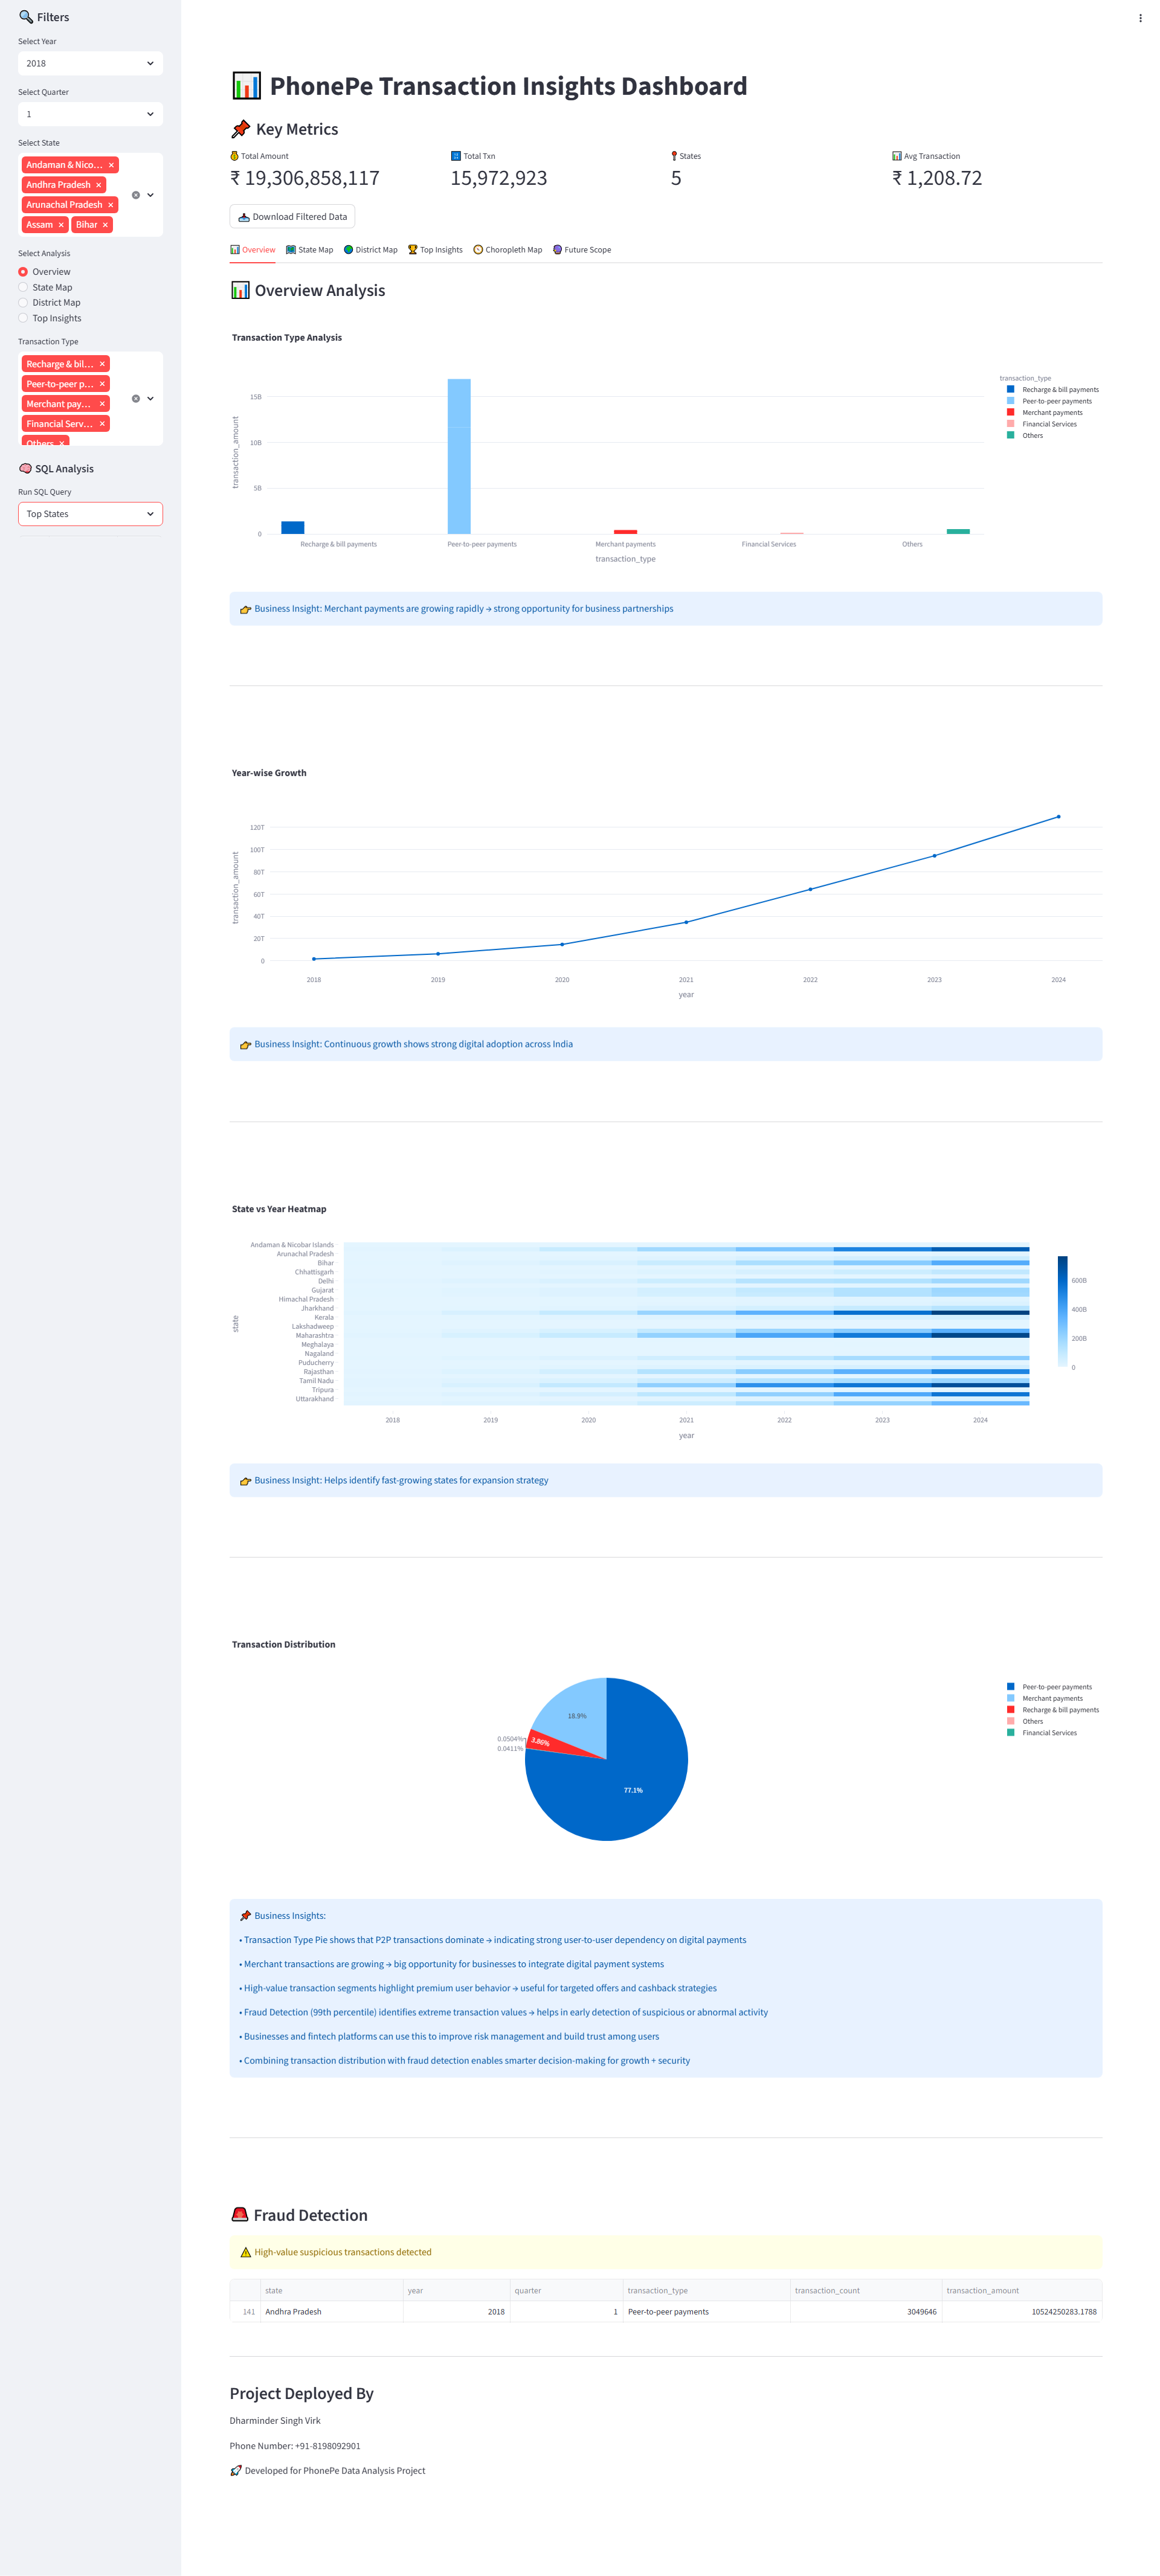

### **_Phase 6.6: Deployment Summary_**

The Streamlit application was deployed to make it accessible for end users through a web interface.

Steps involved in deployment:

- The application code was organized into a single Streamlit script (app.py)
- Required libraries were listed in a requirements.txt file
- The project was tested locally using Streamlit
- The application can be deployed using platforms such as Streamlit Cloud, Render, or Heroku

The deployed application enables users to access the dashboard from anywhere, interact with filters, and explore insights without needing technical knowledge.

### **7: FINAL CONCLUSION**

This project successfully demonstrates the end-to-end data analytics pipeline using PhonePe transaction data. It includes data extraction, transformation, SQL-based analysis, and interactive dashboard development using Streamlit.

The dashboard provides insights into transaction trends, user behavior, and geographical distribution, helping businesses make data-driven decisions. Key highlights include KPI metrics, fraud detection, top-performing regions, and dynamic filtering.

Overall, the project showcases strong skills in data analytics, visualization, and real-world problem solving. This project demonstrates how data analytics and interactive dashboards can transform raw transaction data into meaningful business insights for strategic decision-making.

### **8: FUTURE SCOPE**

- Integration of real-time transaction data using APIs
- Machine learning models for fraud detection
- Advanced geospatial visualization using GeoJSON
- Customer segmentation using clustering algorithms
- Predictive analytics for forecasting future trends
- Deployment on cloud platforms (AWS, Streamlit Cloud)


